<a href="https://colab.research.google.com/github/itu-itis23-jakupi23/README/blob/main/BankTelemarketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.Import and Setup


In [40]:
!pip install imbalanced-learn --quiet

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import(
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

2.Load Dataset

In [42]:
!wget https://archive.ics.uci.edu/static/public/222/bank+marketing.zip

--2026-05-09 07:21:32--  https://archive.ics.uci.edu/static/public/222/bank+marketing.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘bank+marketing.zip.1’

bank+marketing.zip.     [  <=>               ] 999.85K  2.51MB/s    in 0.4s    

2026-05-09 07:21:33 (2.51 MB/s) - ‘bank+marketing.zip.1’ saved [1023843]



In [43]:
!unzip bank+marketing.zip

Archive:  bank+marketing.zip
replace bank.zip? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
 extracting: bank.zip                
 extracting: bank-additional.zip     


In [44]:
!unzip bank.zip

Archive:  bank.zip
replace bank-full.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: bank-full.csv           
  inflating: bank-names.txt          
  inflating: bank.csv                


In [45]:
import os
os.listdir()

['.config',
 'bank-additional.zip',
 'drive',
 'bank-full.csv',
 'bank+marketing.zip.1',
 'bank-names.txt',
 'bank.zip',
 'bank+marketing.zip',
 'bank.csv',
 'sample_data']

In [46]:
file_path = 'bank-full.csv'
df = pd.read_csv(file_path, sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [47]:
print(df.shape)

(45211, 17)


3.Data Exploration

In [48]:
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [50]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [51]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [52]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [53]:
(df['y'].value_counts(normalize=True) * 100).round(2)

,proportion
y,
no,88.3
yes,11.7


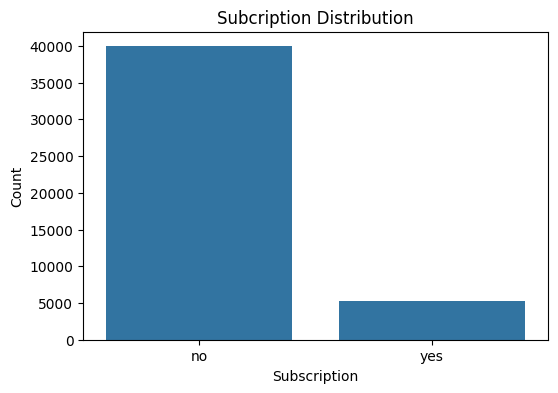

In [54]:
plt.figure(figsize=(6,4))
sns.countplot(x='y', data = df)
plt.title("Subcription Distribution")
plt.xlabel("Subscription")
plt.ylabel("Count")
plt.show()

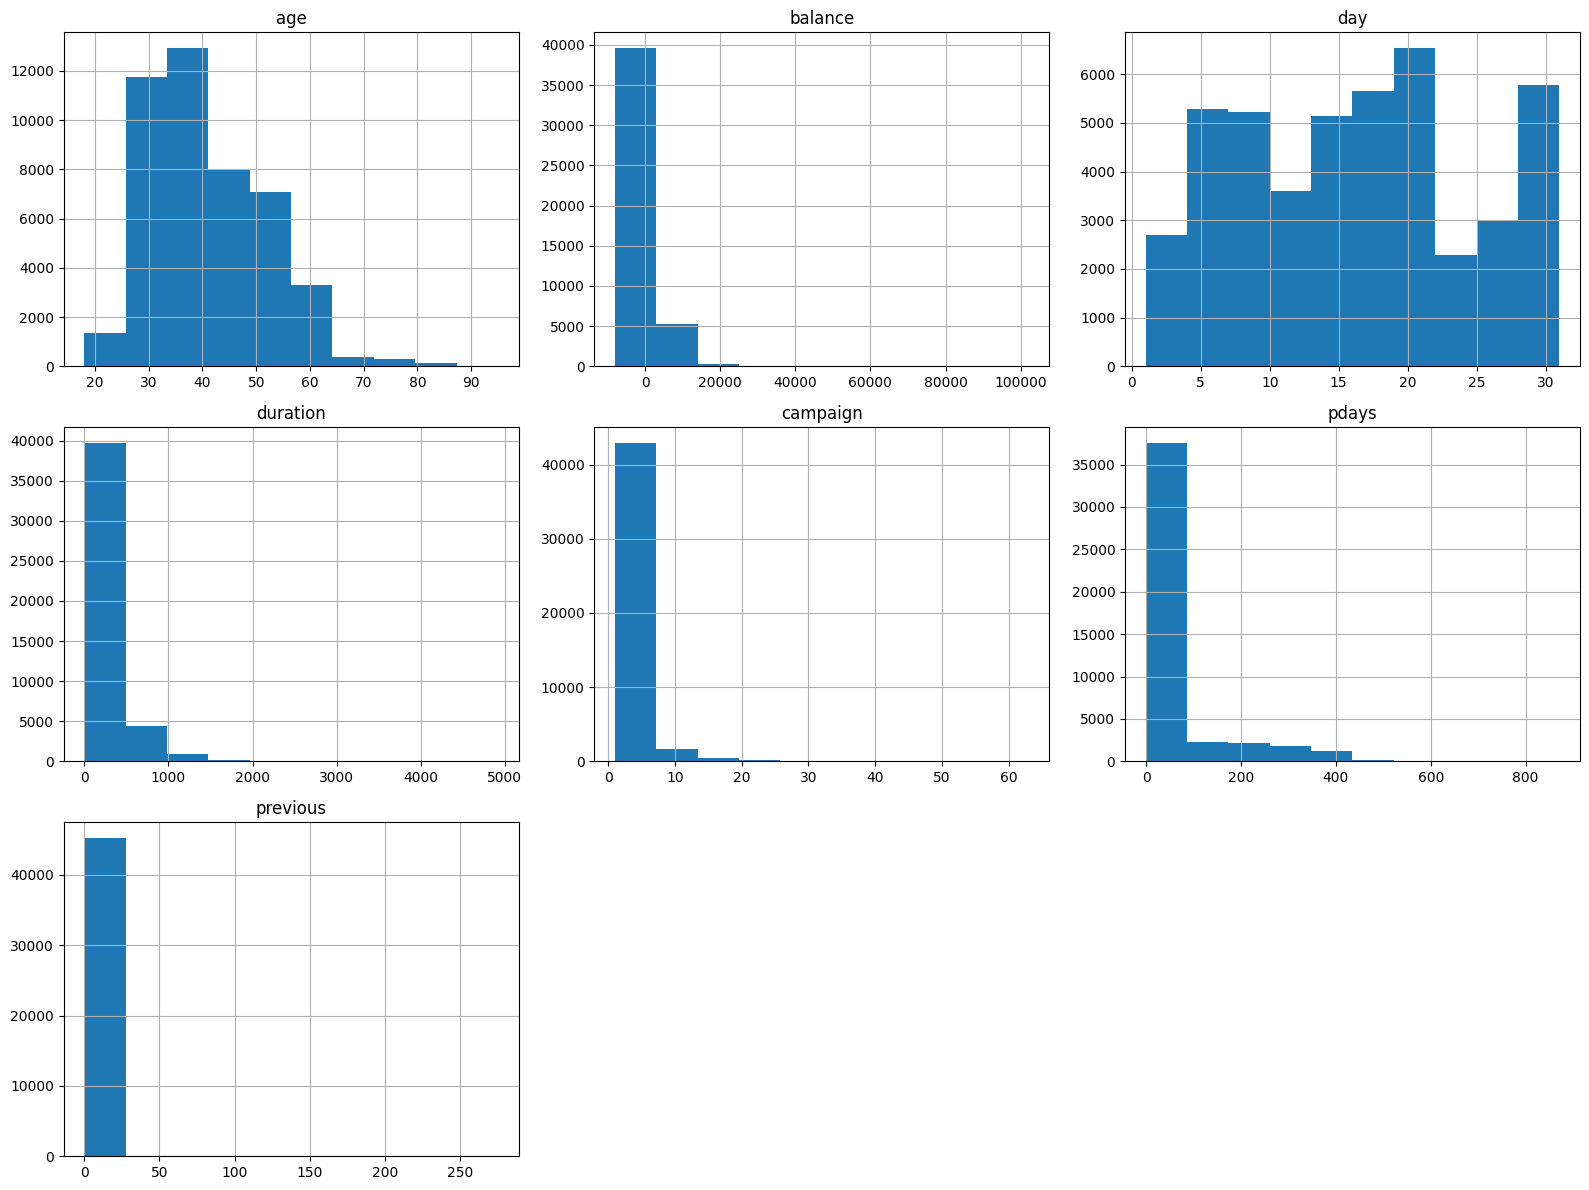

In [55]:
df.hist(figsize=(16,12))
plt.tight_layout()
plt.show()

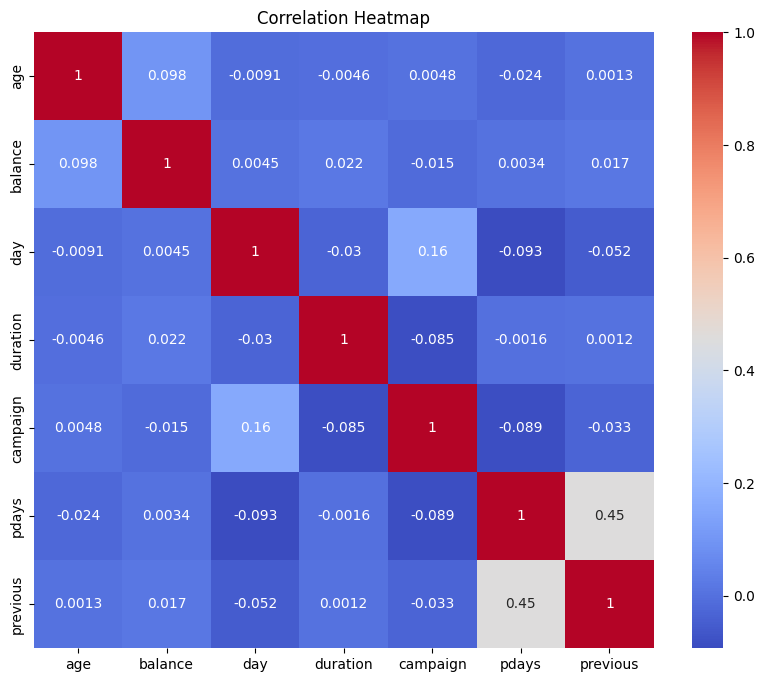

In [56]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot = True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

4.Data Cleaning

In [57]:
df = df.drop_duplicates()
print("New Shape:", df.shape)

New Shape: (45211, 17)


In [58]:
df = df.drop(columns=['duration'])

In [59]:
for col in df.select_dtypes(include='object').columns:
  print(col)
  print(df[col].value_counts())
  print("-"*40)

job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
----------------------------------------
marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
----------------------------------------
education
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
----------------------------------------
default
default
no     44396
yes      815
Name: count, dtype: int64
----------------------------------------
housing
housing
yes    25130
no     20081
Name: count, dtype: int64
----------------------------------------
loan
loan
no     37967
yes     7244
Name: count, dtype: int64
----------------------------------------
contact
contact
cellular     29285
unkno

5.Feature Training

In [60]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [61]:
x = df_encoded.drop('y_yes', axis=1)
y = df_encoded['y_yes']

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
    )

In [63]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [64]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train)

6.Model Training

7.Evaluation

8.Comparison

In [72]:
!git config --global user.name "Atijon Jakupi"
!git config --global user.email "jakupi23@itu.edu.tr"

In [73]:
%cd BBF304E_2526_BankTelemarketing

[Errno 2] No such file or directory: 'BBF304E_2526_BankTelemarketing'
/content/BBF304E_2526_BankTelemarketing


In [74]:
!ls

In [75]:
!cp /content/BankTelemarketing.ipynb .

cp: cannot stat '/content/BankTelemarketing.ipynb': No such file or directory


In [76]:
!git add .
!git commit -m "Initial setup"
!git push

On branch main

Initial commit

nothing to commit (create/copy files and use "git add" to track)
error: src refspec refs/heads/main does not match any
error: failed to push some refs to 'https://github.com/itu-itis23-jakupi23/BBF304E_2526_BankTelemarketing.git'
